In [56]:
import numpy as np 
import matplotlib.pyplot as plt 
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
from torch.utils.data import DataLoader, TensorDataset


In [57]:
# 1. Synthetic Data 
# 2. Plain causal 1d CNN (no dilation) 
# 3. with dilation 
# 4. verify with least squares fit 

In [58]:
np.random.seed(42) 
n = 5000 # samples 
phi1, phi2 = 0.6, -0.3 # cnn will learn this 
sigma = 1.0 # volatility 

y = np.zeros(n) 
y[0] = np.random.randn() * sigma 
y[1] = np.random.randn() * sigma 

# y represents log returns (stationary)
# price series equivalent is y.cumsum() 

# AR(2) generation: y_t = phi1 * y_t-1 + phi2 * y_t-2 + e
for t in range(2, n): 
    eps =  np.random.randn() * sigma 
    y[t] = phi1 * y[t - 1] + phi2 * y[t - 2] + eps 



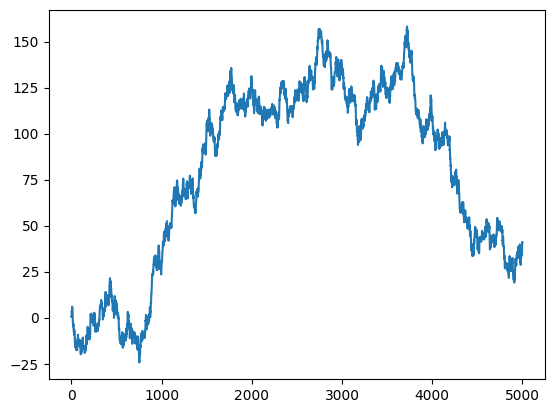

In [59]:
plt.plot(y.cumsum())

<StemContainer object of 3 artists>

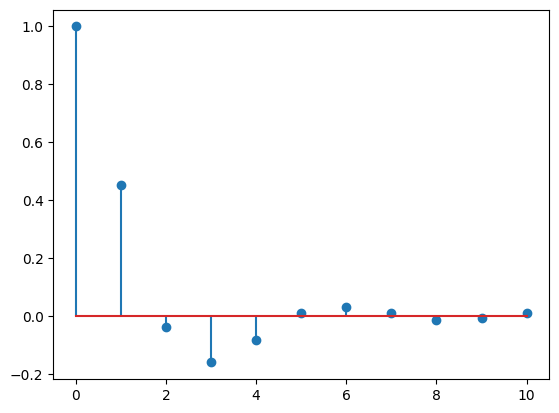

In [60]:
from statsmodels.tsa.stattools import acf 
a = acf(y, nlags=10)
plt.stem(a)

In [61]:
# 1d cnn, no dilation. only shape mechanics + causal padding (asymmetric) 

class CausalCNN(nn.Module): 
    def __init__(self, in_ch: int = 1, hidden: int = 16, kernel: int = 3, verbose: bool = False): 
        super().__init__() 
        self.kernel = kernel 
        self.conv1 = nn.Conv1d(in_channels=in_ch, out_channels=hidden, kernel_size=kernel) 
        # no pooling - architecture 
        self.conv2 = nn.Conv1d(in_channels=hidden, out_channels=hidden, kernel_size=kernel) 
        self.conv3 = nn.Conv1d(in_channels=hidden, out_channels=hidden, kernel_size=kernel) 
        self.head = nn.Linear(hidden, 1) # predict next value 
        # More stacks + nonlinearity between them = more expressiveness
        # can represent more complex (nonlinear, compositional) functions.
        self.verbose = verbose
    
    def forward(self, x): 
        # x shape (batch, 1, time) 
        pad = self.kernel - 1 # =2 for kernel 3 
        # adds padding to x with (pad - left) and (0 right) 
        # [pad1, pad2, x] 
        # if F.pad(x, (1, 1)) - symmetric padding - leakage. 
        # we do asymmentric padding (t-1) only to avoide looking into the future (causal padding)
        x = F.pad(x, (pad, 0)) 
        if self.verbose: 
            print("F.pad ", x.shape)
        x = F.relu(self.conv1(x)) 
        if self.verbose: 
            print("F.relu ", x.shape)
        # outputs 1 value so we have to pad again 
        x = F.pad(x, (pad, 0))  
        if self.verbose: 
            print("F.pad ", x.shape)
        x = F.relu(self.conv2(x)) 
        if self.verbose: 
            print("F.relu ", x.shape)
        x = F.pad(x, (pad, 0)) 
        if self.verbose: 
            print("F.pad ", x.shape)
        x = F.relu(self.conv3(x)) 
        if self.verbose: 
            print("F.relu ", x.shape)

        # take only last time step 
        x = x[:, :, -1] 
        if self.verbose: 
            print("last ", x.shape) 
        prediction = self.head(x).squeeze(-1) 
        if self.verbose: 
            print("prediction ", prediction.shape)
        return prediction
    
model = CausalCNN(verbose=True) 
print(model)

CausalCNN(
  (conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,))
  (conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,))
  (conv3): Conv1d(16, 16, kernel_size=(3,), stride=(1,))
  (head): Linear(in_features=16, out_features=1, bias=True)
)


In [62]:
y_tensor = torch.from_numpy(y).float() 
y_tensor

tensor([ 0.4967, -0.1383,  0.4157,  ...,  3.5624,  2.7773, -0.2504])

In [63]:
# model expects (batch, channels, time). time dimension has to be a  fixed length the model is built for 
# BUT y is 5000 timesteps. Can't feed all 5000 into a model that is designed for 16. 
# so we need to construct training examples by sliding a window through the time series that captures 16 samples. 
# each window becomes one training example: input = past 16 values, target = next value. 
# 5000 timesteps -> ~4984 overlapping (X, Y) pairs to train on 


In [64]:
# pytorch standard way of doing sliding windows
# window = 16
# windows = y_tensor.unfold(0, window+1, 1)
# X = windows[:, :-1].unsqueeze(1) # (N, 1, window) # features  
# Y = windows[:, -1] # labels 

In [65]:
# manual sliding window 
window = 16 
X = [] 
Y = [] 

for t in range(window, len(y)): 
    X.append(y[t-window:t]) # past 16 values 
    Y.append(y[t]) 

X = torch.tensor(X).float().unsqueeze(1) # (N, 1, 16) = (batch, channels, time) 
Y = torch.tensor(Y).float() # (N,) 
print(X.shape)
print(Y.shape)

torch.Size([4984, 1, 16])
torch.Size([4984])


In [66]:
dataset = TensorDataset(X, Y) 
loader = DataLoader(dataset, batch_size=64, shuffle=True) # fine to shuffle

xb, yb = next(iter(loader))
print(xb.shape, yb.shape)

torch.Size([64, 1, 16]) torch.Size([64])


In [67]:
out = model(xb) 
print(out.shape)

F.pad  torch.Size([64, 1, 18])
F.relu  torch.Size([64, 16, 16])
F.pad  torch.Size([64, 16, 18])
F.relu  torch.Size([64, 16, 16])
F.pad  torch.Size([64, 16, 18])
F.relu  torch.Size([64, 16, 16])
last  torch.Size([64, 16])
prediction  torch.Size([64])
torch.Size([64])


In [68]:
from datetime import datetime 
import torch.optim as optim

start = datetime.now() 

model = CausalCNN() 
loss_fn = nn.MSELoss()                                  # ← regression, not classification
optimizer = optim.Adam(model.parameters(), lr=1e-3) 

n_epochs = 50                                            # ← AR(2) needs more than 5 to converge

for epoch in range(n_epochs): 
    model.train() 
    running_loss = 0.0 

    for xb, yb in loader:                                # ← was `for images, labels in loader`
        optimizer.zero_grad()
        pred = model(xb)                                 # ← was `model(xb)` but xb wasn't defined
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    print(f"Epoch {epoch+1:3d}: MSE = {avg_loss:.4f}") 

end = datetime.now() 
training_time = (end - start).total_seconds() 
print(f"Total Training Time: {training_time:.1f} seconds")

Epoch   1: MSE = 1.2711
Epoch   2: MSE = 1.0373
Epoch   3: MSE = 1.0042
Epoch   4: MSE = 1.0006
Epoch   5: MSE = 1.0049
Epoch   6: MSE = 1.0006
Epoch   7: MSE = 0.9979
Epoch   8: MSE = 0.9927
Epoch   9: MSE = 1.0016
Epoch  10: MSE = 0.9940
Epoch  11: MSE = 0.9907
Epoch  12: MSE = 0.9896
Epoch  13: MSE = 0.9886
Epoch  14: MSE = 0.9865
Epoch  15: MSE = 0.9894
Epoch  16: MSE = 0.9847
Epoch  17: MSE = 0.9897
Epoch  18: MSE = 0.9935
Epoch  19: MSE = 0.9858
Epoch  20: MSE = 0.9845
Epoch  21: MSE = 0.9891
Epoch  22: MSE = 0.9853
Epoch  23: MSE = 0.9827
Epoch  24: MSE = 0.9807
Epoch  25: MSE = 0.9871
Epoch  26: MSE = 0.9821
Epoch  27: MSE = 0.9828
Epoch  28: MSE = 0.9831
Epoch  29: MSE = 0.9818
Epoch  30: MSE = 0.9825
Epoch  31: MSE = 0.9812
Epoch  32: MSE = 0.9796
Epoch  33: MSE = 0.9802
Epoch  34: MSE = 0.9778
Epoch  35: MSE = 0.9779
Epoch  36: MSE = 0.9768
Epoch  37: MSE = 0.9792
Epoch  38: MSE = 0.9788
Epoch  39: MSE = 0.9742
Epoch  40: MSE = 0.9770
Epoch  41: MSE = 0.9777
Epoch  42: MSE =

In [69]:
# Chronological split: first 80% = train, last 20% = test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

train_ds = TensorDataset(X_train, Y_train)
test_ds  = TensorDataset(X_test,  Y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)   # shuffle ok within train
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)  # don't shuffle test

In [70]:
from datetime import datetime 
import torch.optim as optim

start = datetime.now() 

model = CausalCNN() 
loss_fn = nn.MSELoss()                                  # ← regression, not classification
optimizer = optim.Adam(model.parameters(), lr=1e-3) 

n_epochs = 50                                            # ← AR(2) needs more than 5 to converge

for epoch in range(n_epochs): 
    model.train() 
    running_loss = 0.0 

    for xb, yb in train_loader:                                # ← was `for images, labels in loader`
        optimizer.zero_grad()
        pred = model(xb)                                 # ← was `model(xb)` but xb wasn't defined
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1:3d}: MSE = {avg_loss:.4f}") 

end = datetime.now() 
training_time = (end - start).total_seconds() 
print(f"Total Training Time: {training_time:.1f} seconds")

Epoch   1: MSE = 1.3046
Epoch   2: MSE = 1.0891
Epoch   3: MSE = 1.0147
Epoch   4: MSE = 1.0011
Epoch   5: MSE = 1.0032
Epoch   6: MSE = 0.9945
Epoch   7: MSE = 1.0000
Epoch   8: MSE = 0.9925
Epoch   9: MSE = 0.9914
Epoch  10: MSE = 0.9968
Epoch  11: MSE = 0.9904
Epoch  12: MSE = 0.9934
Epoch  13: MSE = 0.9861
Epoch  14: MSE = 0.9889
Epoch  15: MSE = 0.9878
Epoch  16: MSE = 0.9871
Epoch  17: MSE = 0.9828
Epoch  18: MSE = 0.9863
Epoch  19: MSE = 0.9790
Epoch  20: MSE = 0.9782
Epoch  21: MSE = 0.9718
Epoch  22: MSE = 0.9767
Epoch  23: MSE = 0.9791
Epoch  24: MSE = 0.9799
Epoch  25: MSE = 0.9774
Epoch  26: MSE = 0.9768
Epoch  27: MSE = 0.9763
Epoch  28: MSE = 0.9743
Epoch  29: MSE = 0.9775
Epoch  30: MSE = 0.9721
Epoch  31: MSE = 0.9678
Epoch  32: MSE = 0.9718
Epoch  33: MSE = 0.9700
Epoch  34: MSE = 0.9742
Epoch  35: MSE = 0.9758
Epoch  36: MSE = 0.9728
Epoch  37: MSE = 0.9672
Epoch  38: MSE = 0.9697
Epoch  39: MSE = 0.9646
Epoch  40: MSE = 0.9690
Epoch  41: MSE = 0.9631
Epoch  42: MSE =

In [71]:
model.eval()
test_loss = 0
with torch.no_grad():
    for xb, yb in test_loader:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        test_loss += loss.item()

test_mse = test_loss / len(test_loader)
print(f"Test MSE: {test_mse:.4f}")
print(f"Bayes-optimal floor (σ²): 1.0")
print(f"Gap: {test_mse - 1.0:.4f}")

Test MSE: 1.0228
Bayes-optimal floor (σ²): 1.0
Gap: 0.0228


Causal Padding - fix for look ahead bias (symmetric padding looks forward into the future) 

Dilation - multi-scale lookback that solves long term dependency without parameter blowup 

Window Construction - correct data handling for timeseries data. 

Bayes Optimal Floor: Sanity check  

Regularization: fn of data quality 

  lag  0: +1.000
  lag  1: +0.655
  lag  2: +0.441
  lag  3: +0.296
  lag  4: +0.191
  lag  5: +0.125
  lag  6: +0.074
  lag  7: +0.036
  lag  8: +0.015
  lag  9: -0.006
  lag 10: -0.006
  lag 11: -0.014
  lag 12: -0.001
  lag 13: +0.004
  lag 14: +0.028
  lag 15: +0.067
  lag 16: +0.112
  lag 17: +0.172
  lag 18: +0.269
  lag 19: +0.388
  lag 20: +0.590
  lag 21: +0.556
  lag 22: +0.450
  lag 23: +0.346
  lag 24: +0.244
  lag 25: +0.172


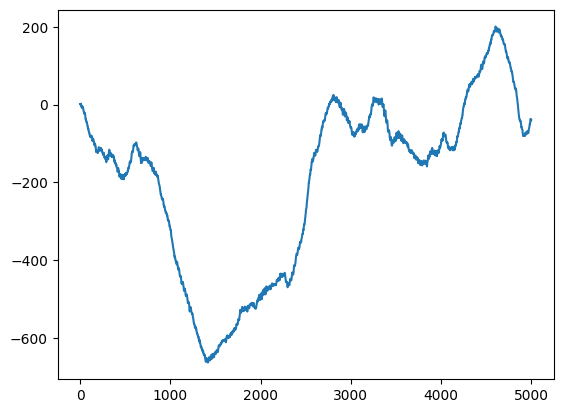

In [72]:
# with dilation 
np.random.seed(67) 
n = 5000
sigma = 1.0

phi = np.zeros(20)
phi[0] = 0.5    # strong recent
phi[19] = 0.4   # strong distant, with no smooth path connecting it

y = np.zeros(n)
y[:20] = np.random.randn(20) * sigma

for t in range(20, n):
    eps = np.random.randn() * sigma
    y[t] = np.dot(phi, y[t-20:t][::-1]) + eps

# Verify ACF — should now show big spikes at lag 1 and lag 20, not uniform
from statsmodels.tsa.stattools import acf
acf_vals = acf(y, nlags=25)
for i, v in enumerate(acf_vals):
    print(f"  lag {i:2d}: {v:+.3f}")

plt.plot(y.cumsum())

In [73]:
print(f"Variance contribution from lags 1-7:  {(phi[:7]**2).sum() / (phi**2).sum():.2%}")
print(f"Variance contribution from lags 8-20: {(phi[7:]**2).sum() / (phi**2).sum():.2%}")

Variance contribution from lags 1-7:  60.98%
Variance contribution from lags 8-20: 39.02%


In [74]:
# 1. Verify you're on AR(20) data, not AR(2)
print(f"y shape: {y.shape}")
print(f"y[:10]: {y[:10]}")  # should be different from your AR(2) values

# 2. Check the ACF — what's the *actual* dependence structure?
from statsmodels.tsa.stattools import acf
acf_vals = acf(y, nlags=25)
for i, v in enumerate(acf_vals):
    print(f"  lag {i:2d}: {v:+.3f}")

y shape: (5000,)
y[:10]: [ 1.12852215  0.14419228 -1.1152586   1.23104654 -0.15465816 -0.5983871
  0.34899214  1.22058965 -0.82870991 -1.1110595 ]
  lag  0: +1.000
  lag  1: +0.655
  lag  2: +0.441
  lag  3: +0.296
  lag  4: +0.191
  lag  5: +0.125
  lag  6: +0.074
  lag  7: +0.036
  lag  8: +0.015
  lag  9: -0.006
  lag 10: -0.006
  lag 11: -0.014
  lag 12: -0.001
  lag 13: +0.004
  lag 14: +0.028
  lag 15: +0.067
  lag 16: +0.112
  lag 17: +0.172
  lag 18: +0.269
  lag 19: +0.388
  lag 20: +0.590
  lag 21: +0.556
  lag 22: +0.450
  lag 23: +0.346
  lag 24: +0.244
  lag 25: +0.172


In [75]:
y_tensor = torch.from_numpy(y).float() 
window = 64
windows = y_tensor.unfold(0, window+1, 1) 
X = windows[:, :-1].unsqueeze(1) # features  
Y = windows[:, -1] # labels  

print(X.shape) 
print(Y.shape) 



torch.Size([4936, 1, 64])
torch.Size([4936])


In [76]:
dataset = TensorDataset(X, Y) 
loader = DataLoader(dataset, batch_size=64, shuffle=True) 
xb, yb = next(iter(loader)) 
print(xb.shape, yb.shape)

torch.Size([64, 1, 64]) torch.Size([64])


In [77]:
out = model(xb) 
print(out.shape)

torch.Size([64])


In [78]:
start = datetime.now() 

model = CausalCNN() 
loss_fn = nn.MSELoss()                                  # ← regression, not classification
optimizer = optim.Adam(model.parameters(), lr=1e-3) 

n_epochs = 50                                            # ← AR(2) needs more than 5 to converge

for epoch in range(n_epochs): 
    model.train() 
    running_loss = 0.0 

    for xb, yb in loader:                                # ← was `for images, labels in loader`
        optimizer.zero_grad()
        pred = model(xb)                                 # ← was `model(xb)` but xb wasn't defined
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    print(f"Epoch {epoch+1:3d}: MSE = {avg_loss:.4f}") 

end = datetime.now() 
training_time = (end - start).total_seconds() 
print(f"Total Training Time: {training_time:.1f} seconds")

Epoch   1: MSE = 1.9445
Epoch   2: MSE = 1.3755
Epoch   3: MSE = 1.3219
Epoch   4: MSE = 1.3090
Epoch   5: MSE = 1.3022
Epoch   6: MSE = 1.2998
Epoch   7: MSE = 1.2807
Epoch   8: MSE = 1.2791
Epoch   9: MSE = 1.3062
Epoch  10: MSE = 1.2980
Epoch  11: MSE = 1.3099
Epoch  12: MSE = 1.2807
Epoch  13: MSE = 1.3002
Epoch  14: MSE = 1.2886
Epoch  15: MSE = 1.2870
Epoch  16: MSE = 1.2786
Epoch  17: MSE = 1.2899
Epoch  18: MSE = 1.2786
Epoch  19: MSE = 1.2894
Epoch  20: MSE = 1.2737
Epoch  21: MSE = 1.2615
Epoch  22: MSE = 1.2657
Epoch  23: MSE = 1.2730
Epoch  24: MSE = 1.2669
Epoch  25: MSE = 1.2749
Epoch  26: MSE = 1.2755
Epoch  27: MSE = 1.2648
Epoch  28: MSE = 1.2625
Epoch  29: MSE = 1.2518
Epoch  30: MSE = 1.2541
Epoch  31: MSE = 1.2576
Epoch  32: MSE = 1.2596
Epoch  33: MSE = 1.2494
Epoch  34: MSE = 1.2524
Epoch  35: MSE = 1.2704
Epoch  36: MSE = 1.2675
Epoch  37: MSE = 1.2548
Epoch  38: MSE = 1.2615
Epoch  39: MSE = 1.2511
Epoch  40: MSE = 1.2425
Epoch  41: MSE = 1.2470
Epoch  42: MSE =

In [79]:
# Chronological split: first 80% = train, last 20% = test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

train_ds = TensorDataset(X_train, Y_train)
test_ds  = TensorDataset(X_test,  Y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)   # shuffle ok within train
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)  # don't shuffle test 

start = datetime.now() 

model = CausalCNN() 
loss_fn = nn.MSELoss()                                  # ← regression, not classification
optimizer = optim.Adam(model.parameters(), lr=1e-3) 

n_epochs = 50                                            # ← AR(2) needs more than 5 to converge

for epoch in range(n_epochs): 
    model.train() 
    running_loss = 0.0 

    for xb, yb in train_loader:                                # ← was `for images, labels in loader`
        optimizer.zero_grad()
        pred = model(xb)                                 # ← was `model(xb)` but xb wasn't defined
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1:3d}: MSE = {avg_loss:.4f}") 

end = datetime.now() 
training_time = (end - start).total_seconds() 
print(f"Total Training Time: {training_time:.1f} seconds")

Epoch   1: MSE = 2.0304
Epoch   2: MSE = 1.4580
Epoch   3: MSE = 1.3341
Epoch   4: MSE = 1.3335
Epoch   5: MSE = 1.3227
Epoch   6: MSE = 1.3199
Epoch   7: MSE = 1.3266
Epoch   8: MSE = 1.3185
Epoch   9: MSE = 1.3116
Epoch  10: MSE = 1.3127
Epoch  11: MSE = 1.3133
Epoch  12: MSE = 1.3055
Epoch  13: MSE = 1.3060
Epoch  14: MSE = 1.3088
Epoch  15: MSE = 1.3006
Epoch  16: MSE = 1.2974
Epoch  17: MSE = 1.2990
Epoch  18: MSE = 1.3013
Epoch  19: MSE = 1.3026
Epoch  20: MSE = 1.2972
Epoch  21: MSE = 1.2998
Epoch  22: MSE = 1.2954
Epoch  23: MSE = 1.2971
Epoch  24: MSE = 1.2923
Epoch  25: MSE = 1.2979
Epoch  26: MSE = 1.2906
Epoch  27: MSE = 1.2893
Epoch  28: MSE = 1.2903
Epoch  29: MSE = 1.2846
Epoch  30: MSE = 1.2931
Epoch  31: MSE = 1.2939
Epoch  32: MSE = 1.2882
Epoch  33: MSE = 1.2900
Epoch  34: MSE = 1.2831
Epoch  35: MSE = 1.2840
Epoch  36: MSE = 1.2790
Epoch  37: MSE = 1.2888
Epoch  38: MSE = 1.2831
Epoch  39: MSE = 1.2795
Epoch  40: MSE = 1.2810
Epoch  41: MSE = 1.2783
Epoch  42: MSE =

In [80]:
model.eval()
test_loss = 0
with torch.no_grad():
    for xb, yb in test_loader:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        test_loss += loss.item()

test_mse = test_loss / len(test_loader)
print(f"Test MSE: {test_mse:.4f}")
print(f"Bayes-optimal floor (σ²): 1.0")
print(f"Gap: {test_mse - 1.0:.4f}")

Test MSE: 1.2377
Bayes-optimal floor (σ²): 1.0
Gap: 0.2377


In [81]:
# causal cnn with dilation 
class CausalCNNDilated(nn.Module): 
    def __init__(
            self, 
            in_ch: int = 1, 
            hidden: int = 16, 
            kernel: int = 3, 
            dilations: tuple = (1, 2, 4, 8, 16), 
            verbose: bool = False
    ): 
        super().__init__() 
        self.kernel = kernel 
        self.dilations = dilations 
        self.verbose = verbose 
        self.convs = nn.ModuleList() 
        for i, d in enumerate(dilations): 
            in_c = in_ch if i == 0 else hidden 
            self.convs.append(nn.Conv1d(in_c, hidden, kernel, dilation=d)) 
        self.head = nn.Linear(hidden, 1) 
    
    def forward(self, x): 
        for d, conv in zip(self.dilations, self.convs): 
            pad = (self.kernel - 1) * d # pad scales with dilations 
            x = F.pad(x, (pad, 0)) 
            x = F.relu(conv(x)) 
            if self.verbose: 
                print(f"after conv (d={d}): {x.shape}") 
        x = x[:, :, -1] 
        return self.head(x).squeeze(-1) 


In [82]:
y_tensor = torch.from_numpy(y).float() 
window = 64 
windows = y_tensor.unfold(0, window+1, 1) 
X = windows[:, :-1].unsqueeze(1) # features  
Y = windows[:, -1] # labels  

print(X.shape) 
print(Y.shape) 

dataset = TensorDataset(X, Y) 
loader = DataLoader(dataset, batch_size=64, shuffle=True) 
xb, yb = next(iter(loader)) 
print(xb.shape, yb.shape)

torch.Size([4936, 1, 64])
torch.Size([4936])
torch.Size([64, 1, 64]) torch.Size([64])


In [83]:
# Chronological split: first 80% = train, last 20% = test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

train_ds = TensorDataset(X_train, Y_train)
test_ds  = TensorDataset(X_test,  Y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)   # shuffle ok within train
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)  # don't shuffle test 

start = datetime.now() 

model = CausalCNNDilated() 
loss_fn = nn.MSELoss()                                  # ← regression, not classification
optimizer = optim.Adam(model.parameters(), lr=1e-3) 

n_epochs = 50                                            # ← AR(2) needs more than 5 to converge

for epoch in range(n_epochs): 
    model.train() 
    running_loss = 0.0 

    for xb, yb in train_loader:                                # ← was `for images, labels in loader`
        optimizer.zero_grad()
        pred = model(xb)                                 # ← was `model(xb)` but xb wasn't defined
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1:3d}: MSE = {avg_loss:.4f}") 

end = datetime.now() 
training_time = (end - start).total_seconds() 
print(f"Total Training Time: {training_time:.1f} seconds")

Epoch   1: MSE = 2.1969
Epoch   2: MSE = 1.4096
Epoch   3: MSE = 1.1776
Epoch   4: MSE = 1.0569
Epoch   5: MSE = 1.0275
Epoch   6: MSE = 1.0076
Epoch   7: MSE = 1.0033
Epoch   8: MSE = 0.9992
Epoch   9: MSE = 0.9948
Epoch  10: MSE = 0.9954
Epoch  11: MSE = 0.9877
Epoch  12: MSE = 0.9883
Epoch  13: MSE = 0.9834
Epoch  14: MSE = 0.9964
Epoch  15: MSE = 0.9716
Epoch  16: MSE = 0.9771
Epoch  17: MSE = 0.9907
Epoch  18: MSE = 0.9735
Epoch  19: MSE = 0.9770
Epoch  20: MSE = 0.9757
Epoch  21: MSE = 0.9652
Epoch  22: MSE = 0.9727
Epoch  23: MSE = 0.9597
Epoch  24: MSE = 0.9634
Epoch  25: MSE = 0.9547
Epoch  26: MSE = 0.9598
Epoch  27: MSE = 0.9537
Epoch  28: MSE = 0.9524
Epoch  29: MSE = 0.9471
Epoch  30: MSE = 0.9614
Epoch  31: MSE = 0.9617
Epoch  32: MSE = 0.9446
Epoch  33: MSE = 0.9407
Epoch  34: MSE = 0.9395
Epoch  35: MSE = 0.9342
Epoch  36: MSE = 0.9328
Epoch  37: MSE = 0.9287
Epoch  38: MSE = 0.9266
Epoch  39: MSE = 0.9326
Epoch  40: MSE = 0.9273
Epoch  41: MSE = 0.9511
Epoch  42: MSE =

In [84]:
model.eval()
test_loss = 0
with torch.no_grad():
    for xb, yb in test_loader:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        test_loss += loss.item()

test_mse = test_loss / len(test_loader)
print(f"Test MSE: {test_mse:.4f}")
print(f"Bayes-optimal floor (σ²): 1.0")
print(f"Gap: {test_mse - 1.0:.4f}")

Test MSE: 1.0598
Bayes-optimal floor (σ²): 1.0
Gap: 0.0598


Synthetic AR(20) data with **sparse coefficients** were run through 2 CNN architectures: 
1. Non-dilated CausalCNN, RF = 7 -> couldn't see lag 20 -> Test MSE 1.24 
2. Dilated Causal CNN [1, 2, 4, 8, 16], 5 layers with a receptive field of 63 (1 + 2 * (1 + 2 + 4 + 8 + 16)), Test MSE 1.06 

Dilation closed 75% of the gap. The architecture's expanded receptive field captured the long-memory term that shallower stacks physically could not reach.